## ORCA - plotting methods

ORCA is a tripolar ocean grid used by the NEMO ocean model and various coupled
climate and weather systems.  It combines a regular latitude–longitude
grid in the Southern Hemisphere with a bipolar grid in the Northern Hemisphere
to avoid a coordinate singularity over the ocean.

Because ORCA data is stored as a 2-D array on an irregular, curvilinear grid,
different plotting methods make different trade-offs between accuracy and speed:

| Method | How it works | Best for |
|---|---|---|
| `grid_cells` | Draws each cell as its true quadrilateral polygon | Seeing exact cell geometry |
| `point_cloud` | Plots a coloured marker at each cell centre | Quick inspection, sparse data |
| `contourf` | Interpolates to a regular grid then draws filled contours | Smooth, publication-quality maps |

This notebook loads an ORCA grid sea surface temperature field and shows all
three methods side-by-side.

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

data = ekd.from_source("sample", "orca.grib")

earthkit-data cache: filesystem usage (97%) exceeds limit (95%) set by 'maximum-cache-disk-usage' config option
earthkit-data cache: trying to free 9.2 GiB
earthkit-data cache: could not free 9.2 GiB


### Shared style

We define a single `Style` object and reuse it across all subplots so the
colour scale is identical in every panel.

In [2]:
import numpy as np
style = ekp.styles.Style(levels=np.arange(14, 20.5, 0.5), colors="Spectral_r", units="celsius")

### All methods side-by-side

Each subplot uses the same domain so the different cell geometries and
interpolation effects are easy to compare.

<div style="padding: 20px; background-color: #D4E5F7; border-left: 6px solid #006EAD; margin-bottom: 15px; width: 95%;">
    <strong>Note</strong>: The first time you plot ORCA data with `contourf`, it is likely to take a very long time, as the underlying software needs to generate a large, complex matrix to do the transformation from the ORCA grid to a regular latitude-longitude grid. The resulting matrix will be <strong>cached</strong>, and it will be much faster the next time you attempt the same plot.
</div>

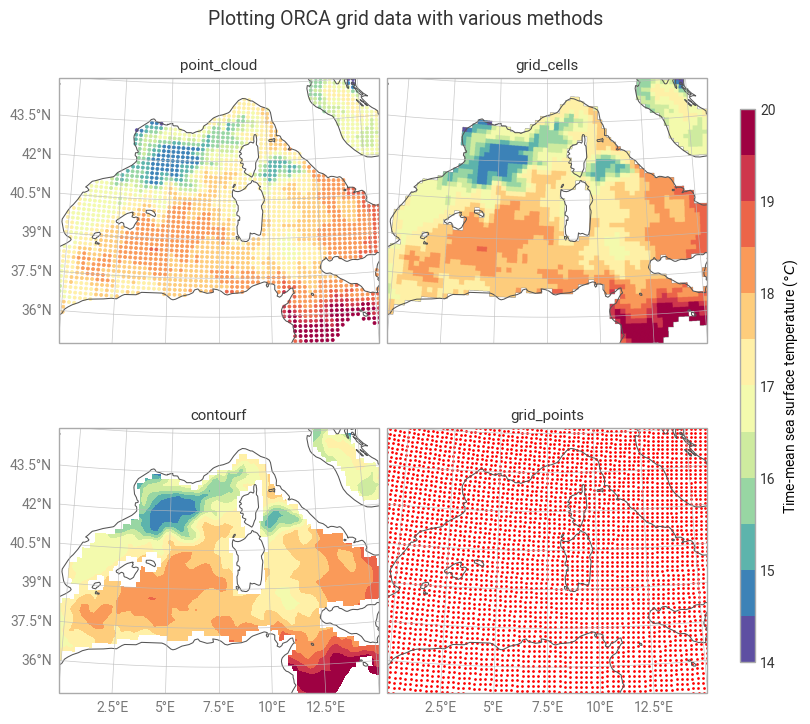

In [3]:
figure = ekp.Figure(rows=2, columns=2, domain=[0, 15, 35, 45])

for method in ["point_cloud", "grid_cells", "contourf", "grid_points"]:
    subplot = figure.add_map()
    getattr(subplot, method)(data, style=style)
    subplot.title(method)

figure.coastlines()
figure.gridlines()

figure.title("Plotting ORCA grid data with various methods")

figure.legend(location="right")

figure.show()

### What to notice

- **`grid_cells`** shows the true ORCA cell boundaries — the curvilinear
  quadrilateral shapes that reflect the tripolar grid geometry.
- **`point_cloud`** places one dot per cell centre.  At this resolution
  the dots are close enough to fill in, but zooming out would reveal gaps.
- **`contourf`** interpolates to a regular grid before contouring, producing a
  smooth result at the cost of some spatial accuracy near sharp gradients.